## `bernet` tutorial

This notebook is a tutorial for a two-dimensional representation using bernstein based neural network.

### 1. Import packages
---

In [1]:
import matplotlib.pyplot as plt
import torch

from bernet import Bernstein, Direction, Head

torch.manual_seed(0)

### 2. Define parameters
---

In [2]:
num_points = 60

# Head for direction 1 (with boundary conditions)
input_dim_1 = 3
output_dim_1 = 5

# Head for direction 2 (free)
input_dim_2 = 3
output_dim_2 = 5

# Boundary condition (direction 1 only)
phi_0 = torch.zeros(num_points ** 2)
phi_1 = torch.ones(num_points ** 2)
dphi_dxi_1 = torch.zeros(num_points ** 2)

# Define parametric directions
xi1_axis = torch.linspace(0, 1, num_points)
xi2_axis = torch.linspace(0, 1, num_points)

xi1_grid, xi2_grid = torch.meshgrid(xi1_axis, xi2_axis, indexing="ij")

xi1 = xi1_grid.reshape(-1)
xi2 = xi2_grid.reshape(-1)

# Latent space
latent1 = torch.randn(1, input_dim_1).expand(xi1.shape[0], -1)
latent2 = torch.randn(1, input_dim_2).expand(xi2.shape[0], -1)

### 3. Boundary condition enforcement
---

Define model and directions

In [3]:
# Define model
model = Bernstein(
    heads=[
        Head(input_dim=input_dim_1, output_dim=output_dim_1),
        Head(input_dim=input_dim_2, output_dim=output_dim_2),
    ],
)

# Define direction inputs
direction_1 = Direction(
    latent=latent1,
    xi=xi1,
    phi_0=phi_0,
    phi_1=phi_1,
    dphi_dxi_1=dphi_dxi_1,
)
direction_2 = Direction(
    latent=latent2,
    xi=xi2,
)

Compute output

In [4]:
with torch.no_grad():
    phi = model.forward([direction_1, direction_2])

Plot the resulting field

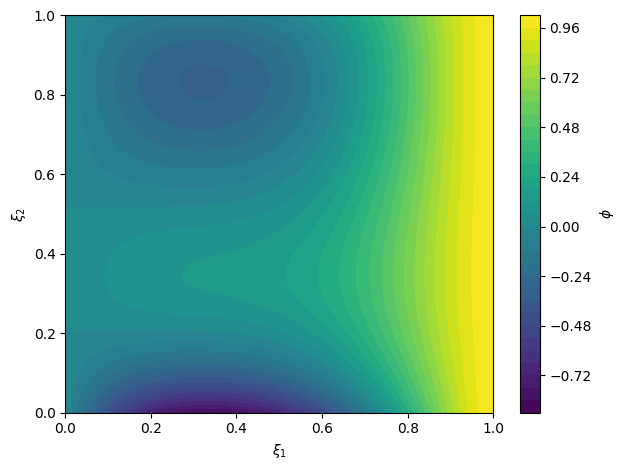

In [5]:
phi_grid = phi.reshape(num_points, num_points)

plt.figure()

cs = plt.contourf(xi1_grid, xi2_grid, phi_grid, levels=30)
plt.colorbar(cs, label=r"$\phi$")

plt.xlabel(r"$\xi_1$")
plt.ylabel(r"$\xi_2$")

plt.tight_layout()
plt.show()